In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# -------- 1. Đọc dữ liệu --------
cols = [
    'letter','x-box','y-box','width','high','onpix','x-bar','y-bar',
    'x2bar','y2bar','xybar','x2ybr','xy2br','x-ege','xegvy','y-ege','yegvx'
]
df = pd.read_csv("data/letter-recognition.data", header=None, names=cols)

In [3]:
# -------- 2. X, y --------
X = df.drop("letter", axis=1)
y = LabelEncoder().fit_transform(df["letter"])

In [4]:
# -------- 3. Train/Test --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# -------- 4. Thử các giá trị k --------
k_values = range(1, 21)   # thử k = 1 → 20
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    # print(f"k = {k:2d} --> Accuracy = {acc:.4f}")

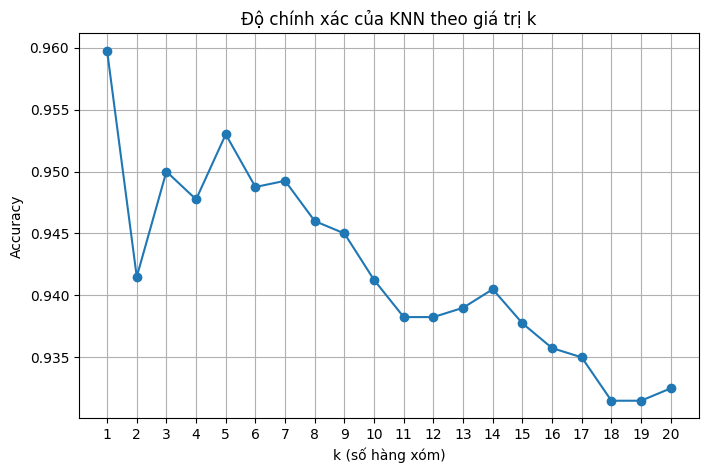

In [6]:
# -------- 5. Vẽ biểu đồ --------
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k (số hàng xóm)")
plt.ylabel("Accuracy")
plt.title("Độ chính xác của KNN theo giá trị k")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [7]:
# -------- 6. Thử dự đoán mẫu với knn có k tốt nhất --------

# Tìm k tốt nhất
best_index = accuracies.index(max(accuracies))
best_k = k_values[best_index]
print(f"Giá trị k tốt nhất: {best_k}, với Accuracy = {accuracies[best_index]:.4f}")

# Huấn luyện lại KNN với k tốt nhất
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)


print(X_test.iloc[[0]])
print("Dự đoán mẫu đầu tiên:", best_knn.predict(X_test.iloc[[0]])[0])
print("Nhãn thật:", y_test[0])

Giá trị k tốt nhất: 1, với Accuracy = 0.9597
      x-box  y-box  width  high  onpix  x-bar  y-bar  x2bar  y2bar  xybar  \
2734      3      5      6     4      4      9      7      3      5      9   

      x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
2734      4      6      3      7      4     10  
Dự đoán mẫu đầu tiên: 17
Nhãn thật: 17
